### Шаг 1: Загрузка данных
Сначала загрузим данные из CSV-файла:

In [40]:
import pandas as pd

# Загрузка данных
titanic_data = pd.read_csv('titanic.csv')

### Шаг 2: Предварительный анализ данных

Перед началом визуализации полезно получить общее представление о данных:

In [43]:
# Просмотр первых строк данных
print(titanic_data.head())

# Получение информации о датафрейме
print(titanic_data.info())

# Описание статистических характеристик
print(titanic_data.describe())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

### Шаг 3: Визуализация данных

Теперь мы можем приступить к визуализации. Начнем с основных графиков, которые помогут понять распределение целевой переменной (выживание) и других признаков.

### График 1: Распределение выживаемости

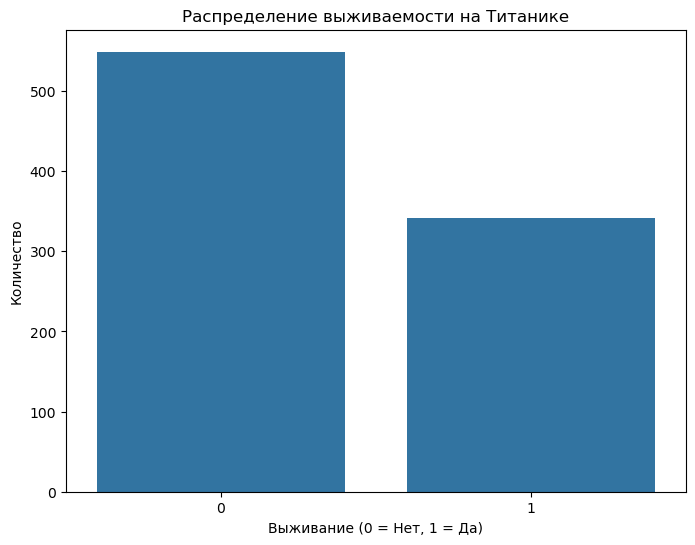

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# График распределения выживаемости
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=titanic_data)
plt.title('Распределение выживаемости на Титанике')
plt.xlabel('Выживание (0 = Нет, 1 = Да)')
plt.ylabel('Количество')
plt.show()

### Комментарий к графику: 
Данный график показывает количество пассажиров, выживших и не выживших. Мы видим, что большее количество пассажиров не выжило.

### График 2: Выживаемость по полу

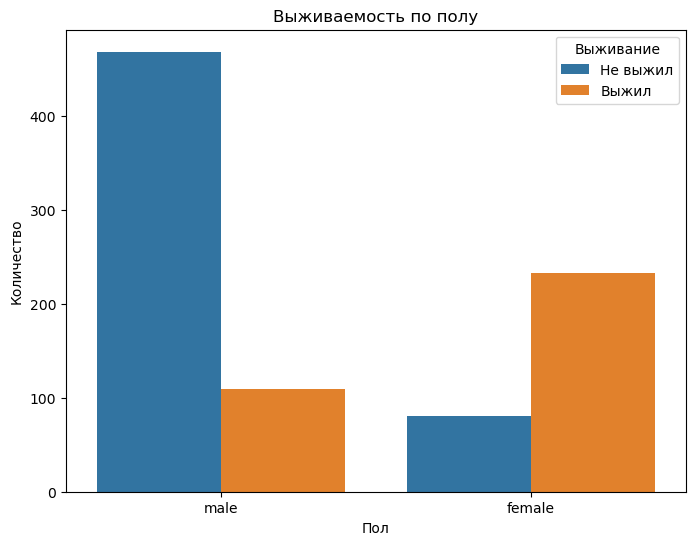

In [51]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=titanic_data)
plt.title('Выживаемость по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.legend(title='Выживание', loc='upper right', labels=['Не выжил', 'Выжил'])
plt.show()

### Комментарий к графику: 
Этот график показывает, как пол влиял на выживаемость. Мы можем заметить, что женщины выживали чаще, чем мужчины.

### Шаг 4: Корреляционный анализ

Теперь давайте проанализируем корреляцию между числовыми переменными и целевой переменной.

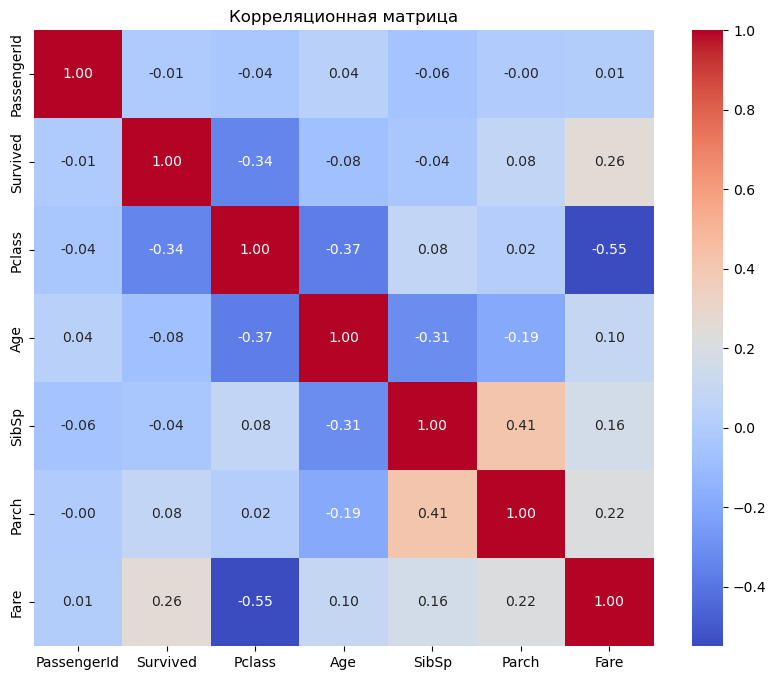

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64
PassengerId: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 2

In [ ]:
# Отбор только числовых колонок
numeric_data = titanic_data.select_dtypes(include=['float64', 'int64'])

# Корреляция между числовыми переменными
correlation_matrix = numeric_data.corr()

# Визуализация корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()
# Проверка на пропуски
print(numeric_data.isnull().sum())

# Проверка на уникальные значения в числовых колонках
for col in numeric_data.columns:
    print(f"{col}: {numeric_data[col].unique()}")
    # Преобразование категориальных переменных в фиктивные переменные
categorical_data = pd.get_dummies(titanic_data, drop_first=True)

# Корреляция между всеми переменными (числовыми и закодированными категориальными)
correlation_matrix = categorical_data.corr()

# Визуализация обновленной корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица с закодированными категориальными переменными')
plt.show()




### Вывод после графика: 
Корреляционная матрица показывает, что возраст (Age) имеет умеренную положительную корреляцию с выживанием. Также мы можем заметить, что количество братьев/сестер (SibSp) и родителей/детей (Parch) имеют небольшую положительную корреляцию с выживанием.

### Заключение

EDA предоставляет мощные инструменты для понимания структуры данных и выявления паттернов. В случае данных о Титанике мы обнаружили, что пол и возраст являются важными факторами, влияющими на выживаемость. Дальнейшие шаги могут включать в себя построение моделей машинного обучения для предсказания выживаемости на основе этих факторов.